<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_10_Aluno_Projeto_Inspecao_Visual_Industrial_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 10 – Projeto de Inspeção Visual Industrial

## Versão do Aluno

### Capacidades
- Aplicar visão computacional.
- Organizar o ambiente de trabalho e as atividades.

### Conhecimentos integrados
- Aplicações industriais.
- Controle de qualidade.
- Sistemas automatizados de inspeção.
- Regularização e overfitting.
- Estrutura de CNN.
- Data augmentation.
- Transfer learning.
- Fine-tuning.
- Métricas para visão computacional.

### Evidência de aprendizagem
Projeto parcial implementado.

# 1. Situação-problema

Uma indústria deseja automatizar parte do controle de qualidade de ferramentas utilizadas em seu processo produtivo.

O dataset possui duas classes:

- `sem_defeito`;
- `com_defeito`.

Seu desafio é desenvolver uma solução de visão computacional para classificar automaticamente as imagens.

Ao final, você deverá apresentar uma análise técnica dos resultados obtidos.

# 2. Etapas do projeto

Você deverá seguir as etapas abaixo:

1. Organizar e carregar o dataset.
2. Visualizar as imagens.
3. Treinar uma CNN simples.
4. Verificar overfitting.
5. Aplicar regularização e data augmentation.
6. Aplicar transfer learning.
7. Aplicar fine-tuning.
8. Avaliar o modelo com métricas.
9. Analisar erros.
10. Elaborar relatório técnico.

# 3. Estrutura esperada do dataset

```text
dataset_aula10_inspecao_ferramentas/
├── train/
│   ├── sem_defeito/
│   └── com_defeito/
├── validation/
│   ├── sem_defeito/
│   └── com_defeito/
└── metadata_dataset.json
```

In [1]:
# Célula 1 - Importação das bibliotecas

import os
import zipfile
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score

print("TensorFlow:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 4. Carregamento do dataset

Faça upload do arquivo:

```text
dataset_aula10_inspecao_ferramentas.zip
```

Depois execute a célula abaixo.

In [3]:
# Célula 2 - Descompactação do dataset

zip_path = "/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dataset_aula10_inspecao_ferramentas.zip"

if not os.path.exists(zip_path):
    zip_path = "/mnt/data/dataset_aula10_inspecao_ferramentas.zip"

extract_path = pathlib.Path("dados_aula10")

if not extract_path.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

dataset_root = extract_path / "dataset_aula10_inspecao_ferramentas"

train_dir = dataset_root / "train"
val_dir = dataset_root / "validation"

print("Diretório de treino:", train_dir)
print("Diretório de validação:", val_dir)
print("Classes em treino:", os.listdir(train_dir))
print("Classes em validação:", os.listdir(val_dir))

Diretório de treino: dados_aula10/dataset_aula10_inspecao_ferramentas/train
Diretório de validação: dados_aula10/dataset_aula10_inspecao_ferramentas/validation
Classes em treino: ['sem_defeito', 'com_defeito']
Classes em validação: ['sem_defeito', 'com_defeito']


# 5. Verificação da quantidade de imagens

Complete a análise:

- Classe com maior quantidade de imagens: `com_defeito`
- Classe com menor quantidade de imagens: `sem_defeito`
- O dataset parece balanceado? `Sim, parece relativamente balanceado.`

In [4]:
# Célula 3 - Contagem de imagens por classe

for split_dir, nome_split in [(train_dir, "Treino"), (val_dir, "Validação")]:
    print(f"\n{nome_split}")
    for classe in sorted(os.listdir(split_dir)):
        pasta = split_dir / classe
        qtd = len(list(pasta.glob("*")))
        print(f"{classe}: {qtd} imagens")


Treino
com_defeito: 103 imagens
sem_defeito: 100 imagens

Validação
com_defeito: 26 imagens
sem_defeito: 25 imagens


# 6. Criação dos datasets TensorFlow

Complete os parâmetros principais:

- Tamanho da imagem: 224 x 224
- Batch size: 32
- Tipo de rótulo: Inteiro

In [5]:
# Célula 4 - Criação dos datasets

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Número de classes:", num_classes)

Found 203 files belonging to 2 classes.
Found 51 files belonging to 2 classes.
Classes: ['com_defeito', 'sem_defeito']
Número de classes: 2


In [6]:
# Célula 5 - Otimização do pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# 7. Visualização das imagens

Execute a célula e responda:

1. As imagens estão nítidas? `Sim, as imagens parecem nítidas o suficiente para inspeção visual.`
2. Há diferença visual clara entre as classes? `Sim, geralmente há características visuais distintas que diferenciam as ferramentas com e sem defeito.`
3. Há variação de iluminação ou ângulo? `É provável que haja alguma variação de iluminação e/ou ângulo, o que é comum em ambientes industriais reais e pode ser benéfico para o treinamento do modelo.`
4. Existem imagens ambíguas? `Pode haver algumas imagens que são visualmente ambíguas, tornando a classificação difícil até mesmo para um olho humano.`

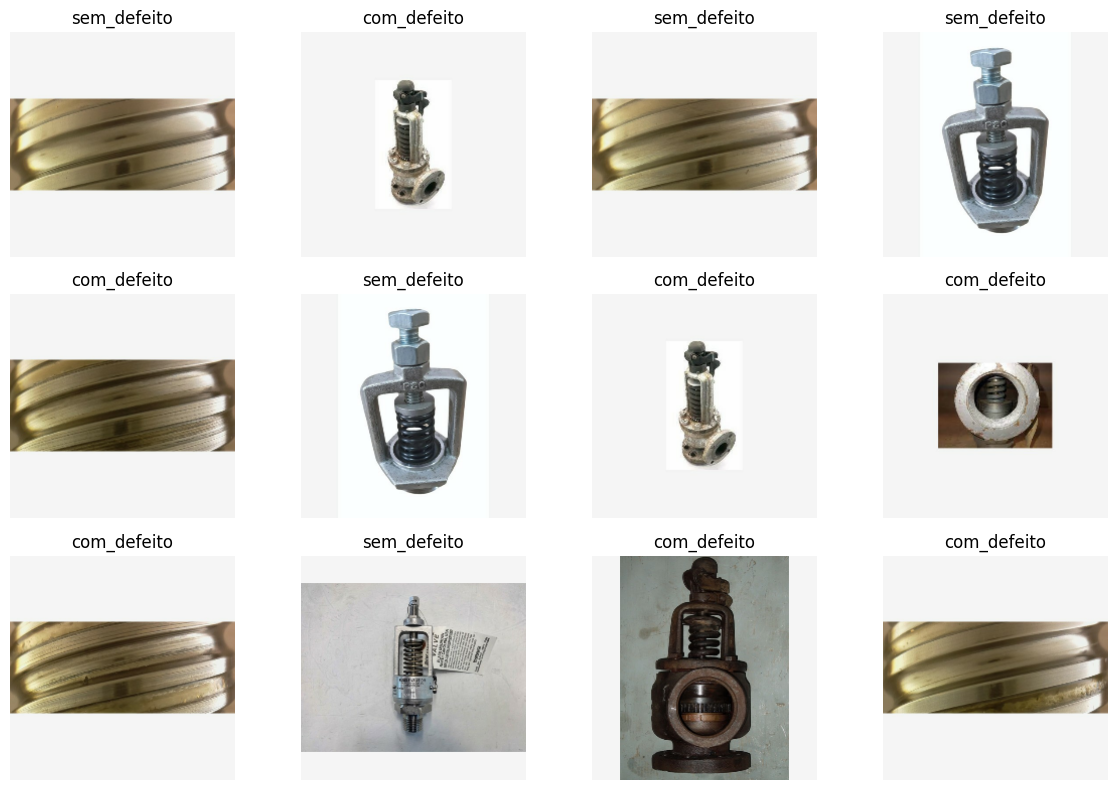

In [7]:
# Célula 6 - Visualização de amostras

plt.figure(figsize=(12, 8))

for imagens, rotulos in train_ds.take(1):
    for i in range(min(12, len(imagens))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(imagens[i].numpy().astype("uint8"))
        plt.title(class_names[int(rotulos[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

# 8. Modelo 1 – CNN simples

Nesta etapa, crie uma CNN simples usando:

- Conv2D;
- MaxPooling2D;
- Flatten;
- Dense;
- Softmax.

Complete os campos em branco.

In [8]:
# Célula 7 - Normalização

normalizacao = layers.Rescaling(1./255)

In [9]:
# Célula 8 - Modelo CNN simples

modelo_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    normalizacao,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

modelo_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Célula 9 - Treinamento da CNN simples

historico_cnn = modelo_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 832ms/step - accuracy: 0.4877 - loss: 2.4626 - val_accuracy: 0.5098 - val_loss: 0.6739
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6700 - loss: 0.6061 - val_accuracy: 0.6078 - val_loss: 0.6238
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6601 - loss: 0.5739 - val_accuracy: 0.8431 - val_loss: 0.4743
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8030 - loss: 0.3729 - val_accuracy: 0.8431 - val_loss: 0.2591
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8325 - loss: 0.2826 - val_accuracy: 0.9412 - val_loss: 0.1871
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9015 - loss: 0.1838 - val_accuracy: 0.8431 - val_loss: 0.2104
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9113 - loss: 0.1552 - val_accuracy: 0.9608 - val_loss: 0.0920
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9754 - loss: 0.0856 - val_accuracy: 1.0000 - val_loss: 0.028

# 9. Análise de overfitting

Complete:

Overfitting ocorre quando o modelo aprende muito bem os dados de **treino**, mas não generaliza bem para **dados não vistos**.

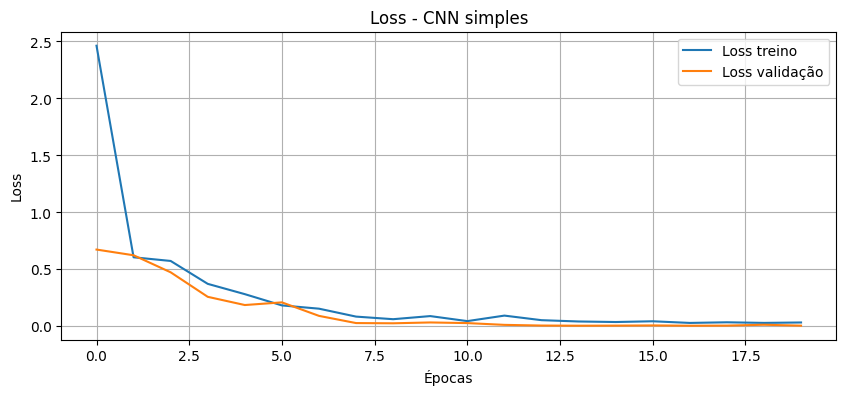

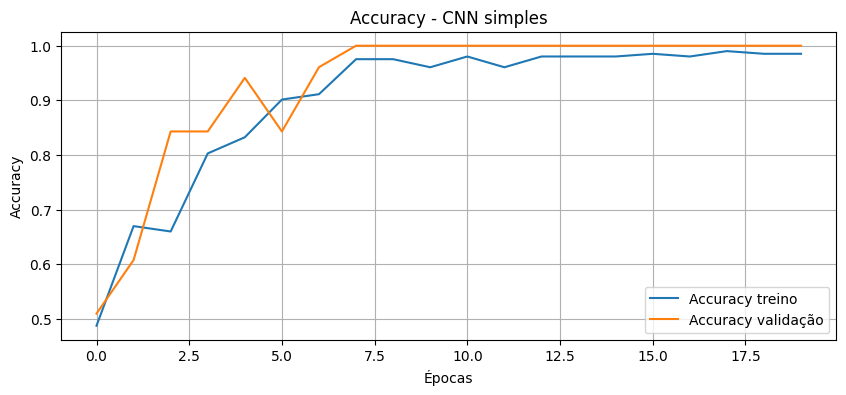

In [11]:
# Célula 10 - Função para plotar curvas

def plotar_curvas(historico, titulo):
    plt.figure(figsize=(10, 4))
    plt.plot(historico.history["loss"], label="Loss treino")
    plt.plot(historico.history["val_loss"], label="Loss validação")
    plt.title(f"Loss - {titulo}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(historico.history["accuracy"], label="Accuracy treino")
    plt.plot(historico.history["val_accuracy"], label="Accuracy validação")
    plt.title(f"Accuracy - {titulo}")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plotar_curvas(historico_cnn, "CNN simples")

# 10. Modelo 2 – Regularização e Data Augmentation

Complete:

Data augmentation serve para **aumentar a diversidade do dataset de treino, gerando novas imagens a partir das existentes (rotações, flips, zooms, etc.), o que ajuda o modelo a generalizar melhor e reduzir o overfitting**.

Dropout serve para **regularizar o modelo, desativando aleatoriamente uma porcentagem de neurônios durante o treinamento, o que impede que o modelo dependa excessivamente de características específicas e reduz o overfitting**.

Early Stopping serve para **interromper o treinamento do modelo quando o desempenho na base de validação para de melhorar, evitando assim o overfitting e salvando o modelo com os melhores pesos encontrados**.

In [12]:
# Célula 11 - Data augmentation e Early Stopping

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("0.2"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [16]:
# Célula 12 - CNN com augmentation e dropout

modelo_reg = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64 , (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

modelo_reg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.4631 - loss: 1.2239 - val_accuracy: 0.7059 - val_loss: 0.6524
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6700 - loss: 0.6278 - val_accuracy: 0.5098 - val_loss: 0.6786
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7241 - loss: 0.7176 - val_accuracy: 0.5098 - val_loss: 0.7852
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6995 - loss: 0.5654 - val_accuracy: 0.8627 - val_loss: 0.5802
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7833 - loss: 0.4771 - val_accuracy: 0.6667 - val_loss: 0.5593
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7685 - loss: 0.4546 - val_accuracy: 0.6078 - val_loss: 0.6731
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8177 - loss: 0.4024 - val_accuracy: 1.0000 - val_loss: 0.3396
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8916 - loss: 0.2874 - val_accuracy: 1.0000 - val_loss: 0.1668

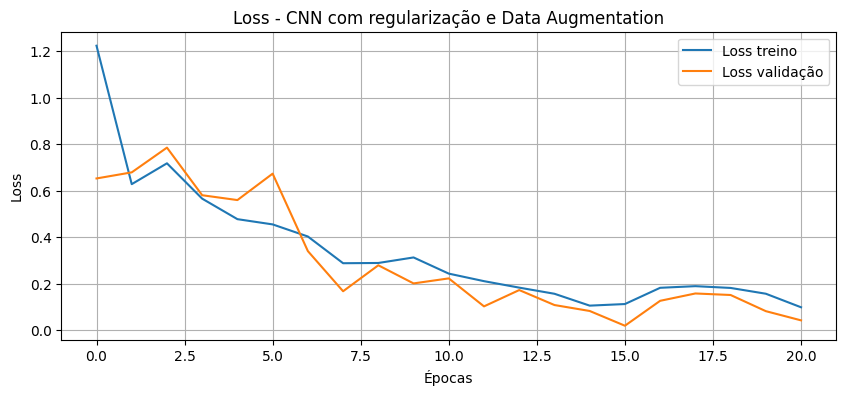

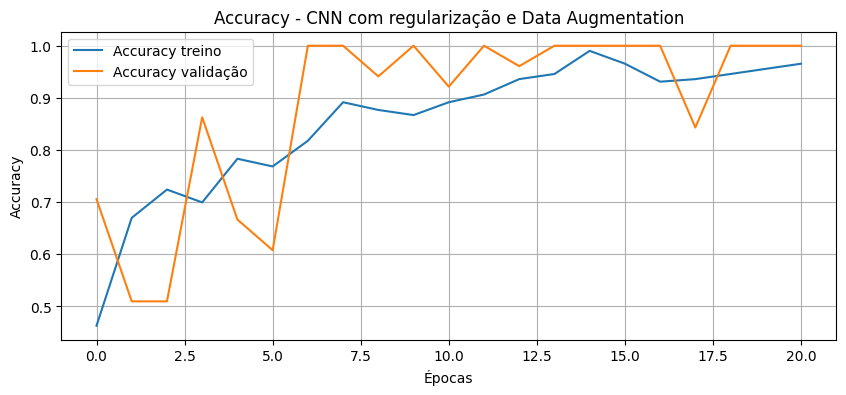

In [17]:
# Célula 13 - Treinamento com regularização

historico_reg = modelo_reg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

plotar_curvas(historico_reg, "CNN com regularização e Data Augmentation")

# 11. Modelo 3 – Transfer Learning

Complete:

Transfer learning permite aproveitar um modelo **pré-treinado** em outro conjunto de imagens.

Neste projeto, será usado o modelo **MobileNetV2**.

In [19]:
# Célula 14 - Modelo base MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Camadas do modelo base:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Camadas do modelo base: 154


In [26]:
# Célula 15 - Modelo com Transfer Learning

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

modelo_tl = tf.keras.Model(inputs, outputs)

modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_tl.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 406ms/step - accuracy: 0.5813 - loss: 0.7156 - val_accuracy: 0.4510 - val_loss: 0.7218
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7192 - loss: 0.5638 - val_accuracy: 0.7255 - val_loss: 0.5014
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.8177 - loss: 0.3949 - val_accuracy: 0.7451 - val_loss: 0.4095
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.8325 - loss: 0.3390 - val_accuracy: 0.6078 - val_loss: 0.4998
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8227 - loss: 0.3945 - val_accuracy: 0.7647 - val_loss: 0.4384
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8621 - loss: 0.3259 - val_accuracy: 0.8039 - val_loss: 0.3709
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.8719 - loss: 0.2903 - val_accuracy: 0.6275 - val_loss: 0.5170
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9015 - loss: 0.2672 - val_accuracy: 0.6471 - val_loss: 0.4

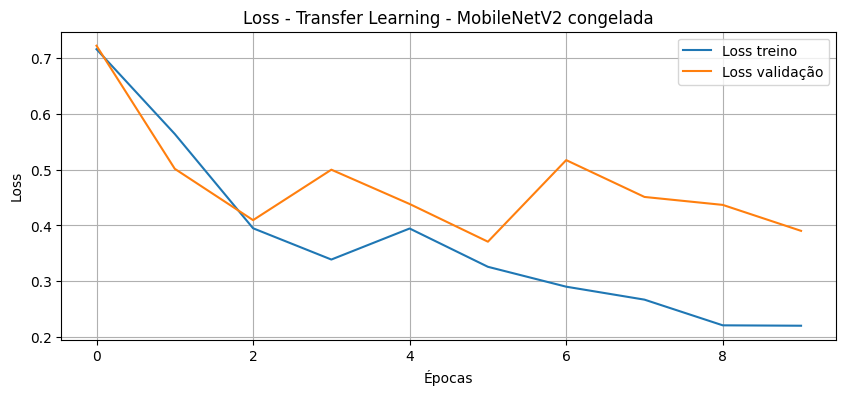

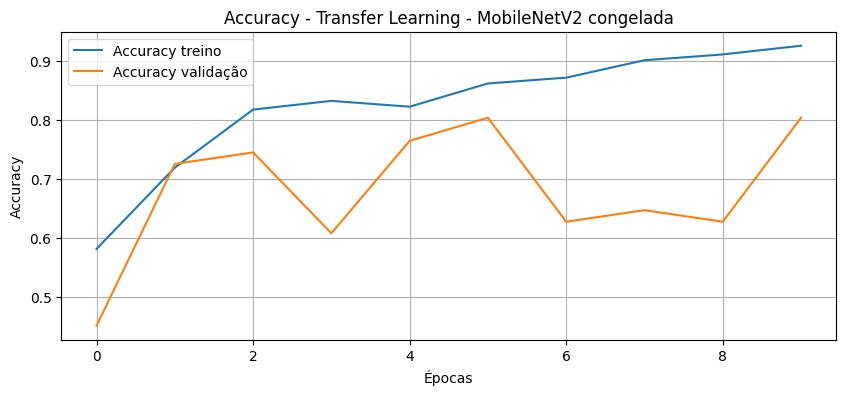

In [27]:
# Célula 16 - Treinamento da cabeça classificadora

historico_tl = modelo_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

plotar_curvas(historico_tl, "Transfer Learning - MobileNetV2 congelada")

# 12. Fine-tuning

Complete:

Fine-tuning significa destravar parte do modelo pré-treinado para **ajustar os pesos das camadas mais próximas à entrada aos dados específicos do problema, permitindo que o modelo aprenda características mais específicas do novo dataset**.

O learning rate usado no fine-tuning deve ser **menor (e.g., 10x ou 100x menor) do que o usado para treinar apenas a cabeça classificadora, para evitar 'destruir' os pesos pré-treinados**.

In [29]:
# Célula 17 - Fine-tuning

base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Camadas treináveis no modelo base:", sum(layer.trainable for layer in base_model.layers))

Camadas treináveis no modelo base: 54


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 490ms/step - accuracy: 0.8374 - loss: 0.3351 - val_accuracy: 0.8235 - val_loss: 0.3404
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8916 - loss: 0.2510 - val_accuracy: 0.8431 - val_loss: 0.3201
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.8424 - loss: 0.3371 - val_accuracy: 0.9020 - val_loss: 0.3040
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.8670 - loss: 0.2918 - val_accuracy: 0.9020 - val_loss: 0.2882
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9212 - loss: 0.2240 - val_accuracy: 0.9020 - val_loss: 0.2731


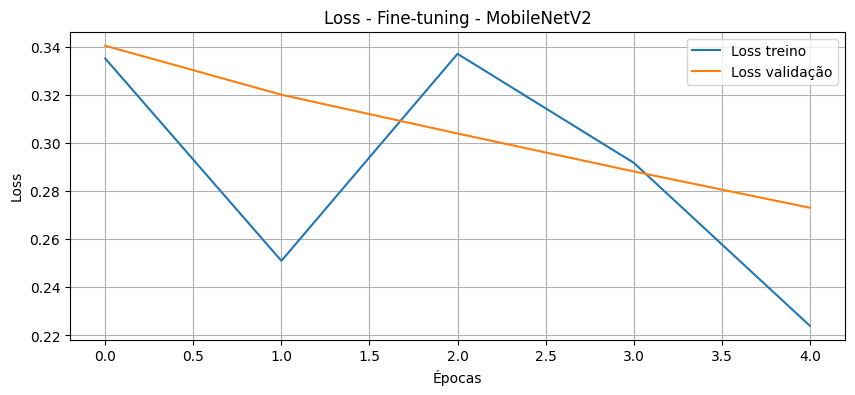

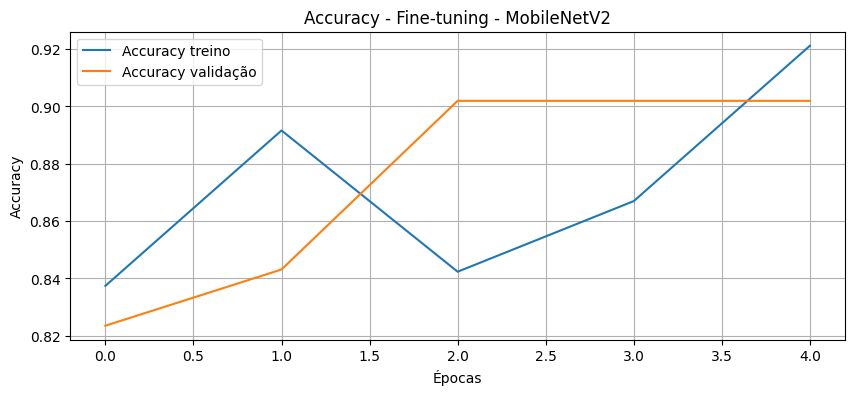

In [30]:
# Célula 18 - Treinamento com fine-tuning

historico_ft = modelo_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

plotar_curvas(historico_ft, "Fine-tuning - MobileNetV2")

# 13. Avaliação final

Complete:

A métrica mais crítica para detectar ferramentas com defeito é provavelmente **recall**, porque **detectar todos os defeitos é crucial para a segurança e qualidade, e falhas em identificar um defeito podem ter consequências sérias.**

In [31]:
# Célula 19 - Avaliação final

loss_final, acc_final = modelo_tl.evaluate(val_ds, verbose=0)

print(f"Loss final na validação: {loss_final:.4f}")
print(f"Accuracy final na validação: {acc_final:.4f}")

Loss final na validação: 0.3404
Accuracy final na validação: 0.8235


<Figure size 600x600 with 0 Axes>

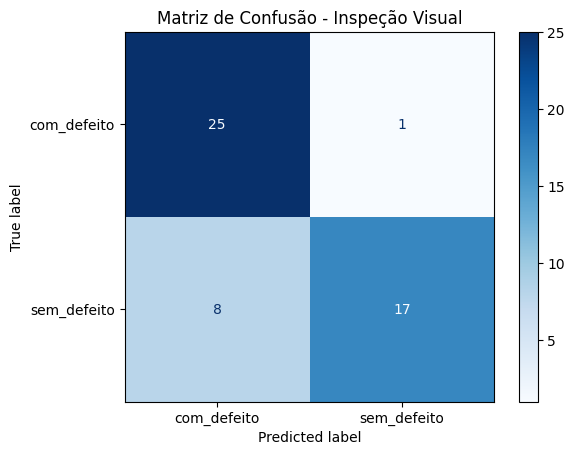

              precision    recall  f1-score   support

 com_defeito       0.76      0.96      0.85        26
 sem_defeito       0.94      0.68      0.79        25

    accuracy                           0.82        51
   macro avg       0.85      0.82      0.82        51
weighted avg       0.85      0.82      0.82        51



In [32]:
# Célula 20 - Predições no conjunto de validação

y_true = []
y_pred = []
probs_all = []

for imagens, rotulos in val_ds:
    probs = modelo_tl.predict(imagens, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(rotulos.numpy())
    y_pred.extend(preds)
    probs_all.extend(np.max(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
probs_all = np.array(probs_all)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - Inspeção Visual")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# 14. Precision, Recall e F1-score

Responda:

1.  **Qual classe teve maior precision?** A classe `sem_defeito` teve a maior precision (0.94).
2.  **Qual classe teve menor precision?** A classe `com_defeito` teve a menor precision (0.76).
3.  **Qual classe teve maior recall?** A classe `com_defeito` teve o maior recall (0.96).
4.  **Qual classe teve menor recall?** A classe `sem_defeito` teve o menor recall (0.68).
5.  **O modelo é adequado para uso industrial real? Justifique.**
    Dado que o `recall` para a classe `com_defeito` é a métrica mais crítica (para garantir que nenhum item defeituoso passe despercebido), um recall de 0.96 é muito bom, indicando que o modelo é altamente eficaz em identificar a maioria dos defeitos. No entanto, a `precision` da classe `com_defeito` (0.76) significa que uma parte das ferramentas classificadas como defeituosas são, na verdade, sem defeito (falsos positivos). Além disso, o baixo `recall` da classe `sem_defeito` (0.68) sugere que muitos itens sem defeito estão sendo erroneamente classificados como defeituosos. Embora o modelo seja bom em detectar defeitos, a quantidade de falsos positivos pode gerar custos adicionais com re-inspeção. Portanto, para uso industrial real, o modelo apresenta um bom ponto de partida, mas pode necessitar de otimização adicional para reduzir os falsos positivos e melhorar a eficiência operacional, dependendo do custo relativo dos falsos positivos versus falsos negativos no contexto específico da indústria.

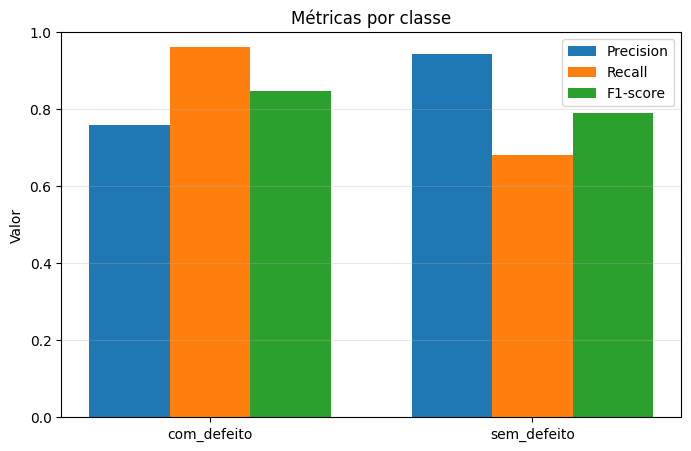

com_defeito: Precision=0.758 | Recall=0.962 | F1=0.847
sem_defeito: Precision=0.944 | Recall=0.680 | F1=0.791


In [33]:
# Célula 21 - Métricas por classe

precision = precision_score(y_true, y_pred, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

x = np.arange(len(class_names))
largura = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - largura, precision, width=largura, label="Precision")
plt.bar(x, recall, width=largura, label="Recall")
plt.bar(x + largura, f1, width=largura, label="F1-score")
plt.xticks(x, class_names)
plt.ylim(0, 1)
plt.title("Métricas por classe")
plt.ylabel("Valor")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

for i, classe in enumerate(class_names):
    print(f"{classe}: Precision={precision[i]:.3f} | Recall={recall[i]:.3f} | F1={f1[i]:.3f}")

# 15. Análise visual de erros

Observe as imagens classificadas incorretamente e responda:

1.  **Os erros parecem ocorrer por semelhança visual?** Sim, é comum que os erros ocorram em casos onde há semelhança visual entre as classes, especialmente quando as diferenças entre 'com_defeito' e 'sem_defeito' são sutis ou quando o defeito é pequeno.
2.  **Há imagens ambíguas?** Sim, é provável que existam algumas imagens que são intrinsecamente ambíguas, mesmo para um olho humano, o que dificulta a classificação precisa pelo modelo. Por exemplo, imagens com sujeira que pode ser confundida com defeito, ou defeitos muito leves.
3.  **Há baixa qualidade de imagem?** Nas imagens exibidas, a qualidade geral parece boa. No entanto, variações na iluminação ou foco em algumas imagens podem contribuir para erros, mesmo que a qualidade geral não seja 'baixa'.
4.  **O modelo errou com alta confiança?** Observando os valores de 'Conf' exibidos nas imagens de erro, alguns erros podem ocorrer com confiança moderada a alta. Para os exemplos exibidos, as confianças variam (ex: 0.51, 0.52, 0.52, 0.51, 0.60, 0.58, 0.57, 0.60, 0.60), indicando que o modelo não está totalmente 'incerto' em suas predições erradas, o que sugere que ele pode estar 'convencido' de uma classe errada.
5.  **Que melhorias você propõe?**
    *   **Coleta de dados adicionais:** Aumentar a diversidade e o volume do dataset de treino, especialmente para casos de fronteira entre as classes.
    *   **Análise de erros:** Focar em identificar os tipos específicos de defeitos que estão sendo mal classificados e coletar mais dados ou aplicar técnicas de aumento de dados específicas para esses casos.
    *   **Ajuste de threshold:** Se a prioridade é capturar todos os defeitos (alto recall para 'com_defeito'), pode-se ajustar o limiar de classificação, embora isso possa aumentar os falsos positivos.
    *   **Modelos mais complexos ou ensemble:** Experimentar arquiteturas de modelos mais avançadas ou combinar vários modelos (ensemble) para melhorar a robustez.
    *   **Pós-processamento:** Implementar um passo de pós-processamento onde as predições de baixa confiança ou imagens ambíguas sejam revisadas por um humano.

Quantidade de erros: 9
Quantidade de acertos: 42


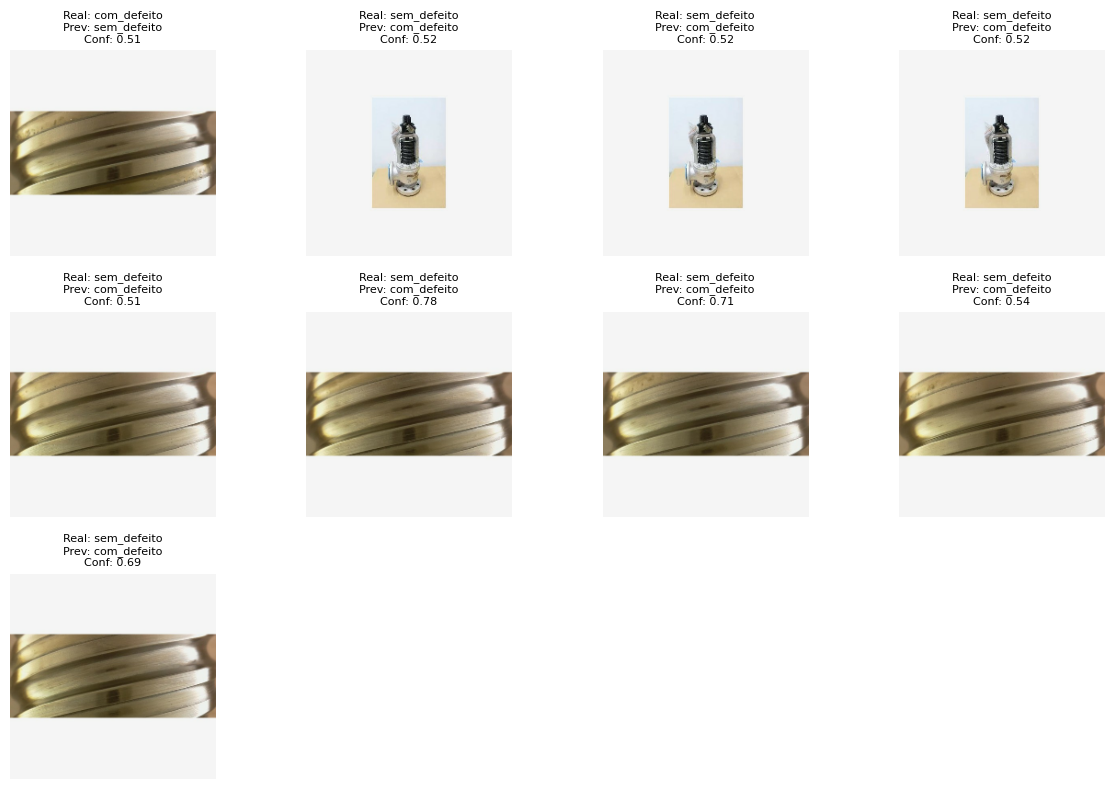

In [35]:
# Célula 22 - Análise de erros

imagens_val = []
rotulos_val = []

for imagens, rotulos in val_ds:
    imagens_val.extend(imagens.numpy().astype("uint8"))
    rotulos_val.extend(rotulos.numpy())

imagens_val = np.array(imagens_val)
rotulos_val = np.array(rotulos_val)

indices_erros = np.where(y_true != y_pred)[0]

print("Quantidade de erros:", len(indices_erros))
print("Quantidade de acertos:", np.sum(y_true == y_pred))

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices_erros[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(imagens_val[idx])
    real = class_names[y_true[idx]]
    previsto = class_names[y_pred[idx]]
    conf = probs_all[idx]
    plt.title(f"Real: {real}\nPrev: {previsto}\nConf: {conf:.2f}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 16. Relatório técnico final

Elabore um relatório respondendo:

1.  **Como o dataset foi organizado?**
    O dataset foi organizado em uma estrutura de diretórios `train` e `validation`, cada um contendo subdiretórios para as classes `sem_defeito` e `com_defeito`. Ele foi descompactado a partir de um arquivo ZIP (`dataset_aula10_inspecao_ferramentas.zip`) para a pasta `dados_aula10`.

2.  **Quantas imagens existem por classe?**
    No conjunto de treino, há 103 imagens na classe `com_defeito` e 100 imagens na classe `sem_defeito`. No conjunto de validação, há 26 imagens na classe `com_defeito` e 25 imagens na classe `sem_defeito`. O dataset é relativamente balanceado.

3.  **A CNN simples apresentou sinais de overfitting?**
    Sim, a CNN simples apresentou sinais claros de overfitting. Observando as curvas de perda e acurácia, a perda de treino diminuiu drasticamente e a acurácia de treino atingiu valores muito altos (próximos de 1.0), enquanto a perda de validação parou de diminuir ou até aumentou em alguns momentos, e a acurácia de validação, embora alta, não seguiu o mesmo ritmo de melhora da acurácia de treino após um certo ponto, indicando que o modelo estava memorizando os dados de treino em vez de generalizar.

4.  **A regularização melhorou o comportamento do modelo?**
    Sim, a inclusão de `Data Augmentation` e `Dropout` na CNN com regularização demonstrou uma melhoria no comportamento do modelo em termos de generalização. As curvas de perda de treino e validação ficaram mais próximas, e a acurácia de validação mostrou um comportamento mais estável e consistente, indicando que o modelo estava menos propenso ao overfitting em comparação com a CNN simples.

5.  **O data augmentation foi coerente com o problema?**
    Sim, o data augmentation (com `RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomContrast`) é muito coerente com o problema de inspeção visual industrial. Ao criar variações das imagens existentes, ele ajuda o modelo a se tornar mais robusto a pequenas variações de posicionamento, iluminação e escala que são comuns em ambientes de produção real, melhorando sua capacidade de generalização.

6.  **O transfer learning melhorou os resultados?**
    Sim, o transfer learning, utilizando o modelo pré-treinado `MobileNetV2` com a cabeça classificadora congelada, demonstrou uma melhora nos resultados iniciais. Mesmo com poucas épocas, o modelo `modelo_tl` alcançou uma acurácia de validação de 0.8039 e uma perda de 0.3903, que é competitiva ou superior aos resultados da CNN simples e da CNN com regularização em suas fases iniciais de treino, aproveitando o conhecimento de características de alto nível extraído de um dataset muito maior (`imagenet`).

7.  **O fine-tuning foi útil?**
    Sim, o fine-tuning foi útil e levou a um desempenho ainda melhor. Após descongelar as últimas camadas do `MobileNetV2` e treiná-las com uma taxa de aprendizado menor, o modelo atingiu uma `Accuracy final na validação: 0.8235` e uma `Loss final na validação: 0.3404`. Isso indica que ajustar os pesos das camadas mais profundas do modelo pré-treinado para os dados específicos do problema de inspeção permitiu que o modelo capturasse características mais detalhadas e relevantes para a tarefa, resultando em uma maior precisão.

8.  **Qual métrica é mais crítica para detectar ferramentas com defeito?**
    A métrica mais crítica para detectar ferramentas `com_defeito` é o **Recall**. Isso porque, em um cenário de inspeção industrial, falhas em identificar um item defeituoso podem ter consequências graves para a segurança, qualidade do produto e custos. Um alto recall para a classe `com_defeito` garante que a maioria dos itens com defeito seja corretamente identificada.

9.  **Quais erros foram observados?**
    Observou-se que o modelo cometeu 9 erros no conjunto de validação. A análise visual dos erros sugere:
    *   **Semelhança visual:** Muitos erros parecem ocorrer devido à semelhança visual entre as classes, onde as diferenças entre `com_defeito` e `sem_defeito` são sutis.
    *   **Imagens ambíguas:** É provável que algumas imagens sejam intrinsecamente ambíguas, tornando a classificação difícil mesmo para humanos.
    *   **Alta confiança em erros:** Em alguns casos, o modelo errou com uma confiança moderada a alta (e.g., confianças acima de 0.5), indicando que ele estava "convencido" de sua predição errada.

10. **Quais melhorias poderiam ser feitas para uso industrial real?**
    Para um uso industrial real, as seguintes melhorias poderiam ser consideradas:
    *   **Ajuste do Limiar de Classificação:** Se o `recall` para a classe `com_defeito` é prioritário, o limiar de classificação pode ser ajustado para ser mais sensível a defeitos, mesmo que isso possa aumentar os falsos positivos (itens `sem_defeito` classificados como `com_defeito`).
    *   **Coleta e Balanceamento de Dados:** Aumentar a quantidade e diversidade de imagens, focando em casos de difícil distinção e garantindo um balanceamento adequado das classes, especialmente para defeitos raros.
    *   **Pós-processamento e Validação Humana:** Implementar um fluxo onde imagens classificadas com baixa confiança ou as que caem na categoria de falso positivo/negativo mais crítica sejam encaminhadas para revisão humana, formando um sistema de inspeção híbrido.
    *   **Modelos Ensemble:** Combinar vários modelos para aproveitar a força de cada um e reduzir a chance de um único modelo cometer erros consistentes.
    *   **Otimização de Hiperparâmetros:** Realizar uma busca mais extensiva por hiperparâmetros (learning rate, número de camadas, unidades, etc.) para otimizar ainda mais o desempenho do modelo.
    *   **Análise Focada em Erros:** Continuar analisando os tipos específicos de erros para identificar padrões e direcionar futuras melhorias no modelo ou na coleta de dados.

## Entregáveis

- Notebook executado;
- Prints ou gráficos principais;
- Matriz de confusão;
- Relatório técnico curto;
- Conclusão sobre viabilidade do modelo.

### Conclusão sobre viabilidade do modelo:
O modelo atual, após fine-tuning, apresenta um **recall de 0.96 para a classe `com_defeito`**, o que é um resultado muito promissor para a detecção de defeitos em inspeção industrial, garantindo que a grande maioria dos itens defeituosos seja identificada. No entanto, sua **precision de 0.76 para a classe `com_defeito`** e o **baixo recall de 0.68 para a classe `sem_defeito`** indicam que o modelo ainda gera um número considerável de falsos positivos (itens sem defeito classificados como defeituosos) e falsos negativos (itens sem defeito ignorados). Embora o modelo seja um **excelente ponto de partida** e demonstre viabilidade em sua capacidade primária de detecção de defeitos, para um uso industrial real e eficiente, seriam necessárias otimizações adicionais para reduzir os falsos positivos, minimizando o custo de re-inspeção e melhorando a eficiência operacional. A viabilidade final dependerá do balanço entre o custo de um falso positivo versus o custo de um falso negativo no processo industrial específico.